# MDR-TS v15.4
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v15.4
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base_1.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

I'm trying to gain some insights on why RF is outperforming XGB by so much. It should not be true if solely looking at theory -- XGB should always outperform RF on tabular data


For other info see `MDR-TS-v1.0`

## 0. Imports

In [1]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [3]:
# Project paths
VERSION = "v15"
SUBVERSION = "v15.4"
RUN_NAME = "mdr_ts_v15_4"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v15/v15.4

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_6.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_6.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_6.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/test.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 489

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


## 4. Data Sanity Checks

In [6]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
        "SMAP_sm_pm_interp_ema02",
        "V_rollmin_LST_modis_kobs30",
        "D_sin_DOY",
        "G_rain_sum_3d",
        "V_ema_G_API_kobs7",
        "V_rollmin_G_API_kobs30",
        "G_rain_sum_7d",
        "C_lag_LST_modis_kobs30",
        "C_lag_G_API_kobs1",
        "V_ema_G_API_kobs14",
        "V_rollmean_G_API_kobs14",
        "G_API",
        "A_pct_G_API",
        "V_rollcv_G_API_kobs30",
        "G_DSLR",
        "SMAP_ampm_diff_interp",
        "V_rollmax_G_API_kobs30",
        "V_rollmin_G_API_kobs7",
        "V_ema_G_API_kobs30",
        "V_rollmean_s2_b11_kobs7",
        "V_ema_LST_modis_kobs7",
        "C_smm_G_API_alpha0.85_n5",
        "C_lag_G_API_kobs5",
        "V_rollmean_G_API_kobs7",
        "C_lag_s2_b11_kobs30",
        "D_z_LST_modis",
        "A_d_G_API_kobs1",
        "V_rollcv_LST_modis_kobs30",
        "V_rollcv_G_API_kobs7",
        "V_rollstd_LST_modis_kobs30",
        "A_d_E_SAR_diff_kobs14",
        "C_lag_G_API_kobs6",
        "V_rollrng_F_NDMI_kobs7",
        "V_rollcv_G_API_kobs14",
        "C_lag_LST_modis_kobs6",
        "A_d_E_SAR_diff_kobs30",
        "A_d_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollrange7",
        "V_rollstd_LST_modis_kobs14",
        "D_fft_ent_E_SAR_ratio_kobs30",
        "A_d_E_SAR_diff_kobs5",
        "SMAP_sm_pm_interp_rollrange7",
        "V_rollstd_F_NDMI_kobs7",
        "V_rollstd_E_SAR_ratio_kobs7",
        "V_rollrng_E_SAR_diff_kobs7",
        "V_rollstd_s2_b12_kobs7",
        "A_grad_E_SAR_diff_kobs14",
        "D_fft_dom_LST_modis_kobs30",
        "V_rollcv_s2_b12_kobs7",
        "A_d_E_SAR_ratio_kobs5",
        "D_fft_ent_LST_modis_kobs30",
        "V_rollstd_F_NDVI_kobs7",
        "A_grad_s2_b12_kobs7",
        "A_pct_F_NDVI",
        "A_d_s2_b12_kobs2",
        "A_grad_E_SAR_diff_kobs30",
        "A_d_F_NDVI_kobs2",
        "A_grad_E_SAR_diff_kobs7",
        "SMAP_sm_interp_rollrange7",
        "A_d_s2_b12_kobs7",
        "A_d_F_NDVI_kobs1",
        "V_rollcv_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollstd7",
        "V_rollstd_SMAP_sm_interp_kobs7",
        "A_d_s2_b12_kobs5",
        "A_pct_SMAP_sm_interp",
        "SMAP_sm_am_interp_pctchg",
        "V_rollrng_SMAP_sm_interp_kobs7",
        "SMAP_sm_interp_pctchg",
        "A_d_E_SAR_diff_kobs2",
        "G_DSLR_isnan",
        "SMAP_sm_pm_interp_mask",
        "SMAP_sm_interp_mask",
        "SMAP_sm_am_interp_mask",
        "SMAP_sm_am_interp_diff1",
        "SMAP_sm_interp_rollstd7",
        "SMAP_sm_interp_diff1",
        "V_rollstd_E_SAR_diff_kobs7",
        "A_grad_s2_b12_kobs14",
        "A_d_E_SAR_ratio_kobs7",
        "A_grad_LST_modis_kobs14",
        "A_d_SMAP_sm_interp_kobs1",
        "SMAP_sm_pm_interp_pctchg",
        "A_grad_E_SAR_ratio_kobs7",
        "A_d_E_SAR_diff_kobs1",
        "A_d_E_SAR_diff_kobs7",
        "SMAP_sm_pm_interp_diff1",
        "A_d_F_NDVI_kobs5",
        "A_d_E_SAR_ratio_kobs2",
        "A_d_G_API_kobs5",
        "A_d_SMAP_sm_interp_kobs2",
        "D_fft_dom_E_SAR_ratio_kobs30",
        "SMAP_sm_pm_interp_rollstd7",
        "V_rollrng_s2_b12_kobs7",
        "V_rollrng_F_NDVI_kobs7",
        "A_d_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_ratio",
        "V_rollstd_SMAP_sm_interp_kobs30",
        "A_d_E_SAR_ratio_kobs1",
        "A_pct_LST_modis",
        "A_grad_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_diff",
        "SMAP_sm_interp_grad7",
        "A_grad_SMAP_sm_interp_kobs7",
        "A_d_LST_modis_kobs1",
        "V_rollcv_E_SAR_diff_kobs7",
        "A_d_s2_b11_kobs5",
        "V_rollstd_LST_modis_kobs7",
]

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 108
  Target:   soil_moisture_5cm


In [7]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[WARN] station Touchet_WA_824: missing split data (train=3311, val=0, test=170)

[WARNING] 1 station(s) have temporal leakage or split issues.


In [8]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Touchet_WA_824:
    train max date: 2020-10-28 00:00:00
    val   min date: NaT


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     16972
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2829
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [10]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (16972, 108)
  X_val:   (2919, 108)
  X_test:  (2829, 108)
  y_train: (16972,)


### 6.2 Feature Overview

In [11]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
A_pct_G_API,76.666423,9980.235936,-0.100000,1.300000e+06
C_smm_G_API_alpha0.85_n5,135.545656,157.525647,0.000000,1.168583e+03
V_rollmax_G_API_kobs30,74.219122,72.224672,0.225530,4.087574e+02
C_lag_G_API_kobs1,43.039290,50.742830,0.000000,4.087574e+02
G_API,43.040359,50.740737,0.000000,4.087574e+02
...,...,...,...,...
V_rollstd_E_SAR_diff_kobs7,0.001309,0.003050,0.000000,4.728213e-02
A_grad_SMAP_sm_interp_kobs14,-0.000013,0.002882,-0.014076,1.960790e-02
A_grad_E_SAR_diff_kobs7,0.000005,0.001162,-0.013485,1.495192e-02
A_grad_E_SAR_diff_kobs14,0.000005,0.000749,-0.009747,7.147361e-03


### 6.4 Baseline Model Definition

In [12]:
DEEP_SEARCH = 40

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

In [13]:
XGB_PARAMS = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,

    subsample=0.9,
    reg_lambda=2.0,
    reg_alpha=0.05,
    n_estimators=4000,
    min_child_weight=3,
    max_depth=7,
    learning_rate=0.05,
    gamma=0.0,
    colsample_bytree=0.75,
)

model_xgb = XGBRegressor(**XGB_PARAMS)

MODEL_CONFIG_FINAL = model_xgb.get_params()

print("\nUsing fixed XGB params:")
for k in [
    "n_estimators","max_depth","learning_rate","min_child_weight","gamma",
    "subsample","colsample_bytree","reg_alpha","reg_lambda"
]:
    print(f"  {k}: {MODEL_CONFIG_FINAL.get(k)}")


Using fixed XGB params:
  n_estimators: 4000
  max_depth: 7
  learning_rate: 0.05
  min_child_weight: 3
  gamma: 0.0
  subsample: 0.9
  colsample_bytree: 0.75
  reg_alpha: 0.05
  reg_lambda: 2.0


In [14]:
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=1000,
)

yhat_train = model_xgb.predict(X_train)
yhat_val   = model_xgb.predict(X_val)
yhat_test  = model_xgb.predict(X_test)

print("\nXGB predictions generated")
print("  yhat_train:", yhat_train.shape)
print("  yhat_val:  ", yhat_val.shape)
print("  yhat_test: ", yhat_test.shape)

print("\nRMSE")
print("  train:", rmse(y_train, yhat_train))
print("  val:  ", rmse(y_val,   yhat_val))
print("  test: ", rmse(y_test,  yhat_test))

[0]	validation_0-rmse:0.09801	validation_1-rmse:0.09979
[1000]	validation_0-rmse:0.00450	validation_1-rmse:0.04079
[2000]	validation_0-rmse:0.00245	validation_1-rmse:0.04074
[3000]	validation_0-rmse:0.00191	validation_1-rmse:0.04073
[3999]	validation_0-rmse:0.00174	validation_1-rmse:0.04073

XGB predictions generated
  yhat_train: (16972,)
  yhat_val:   (2919,)
  yhat_test:  (2829,)

RMSE
  train: 0.0017379010794451096
  val:   0.040728994371265426
  test:  0.05192666924627716


## 7. Training Loop

In [15]:
RF_PARAMS = dict(
    n_estimators=1600,
    min_samples_split=20,
    min_samples_leaf=2,
    max_features="sqrt",
    max_depth=None,
    n_jobs=-1,
    random_state=SEED,
    bootstrap=True,
)

model_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(**RF_PARAMS)),
])

MODEL_CONFIG_RF = {
    "n_estimators": model_rf.named_steps["model"].n_estimators,
    "max_depth": model_rf.named_steps["model"].max_depth,
    "min_samples_leaf": model_rf.named_steps["model"].min_samples_leaf,
    "min_samples_split": model_rf.named_steps["model"].min_samples_split,
    "max_features": model_rf.named_steps["model"].max_features,
    "n_jobs": model_rf.named_steps["model"].n_jobs,
    "random_state": model_rf.named_steps["model"].random_state,
    "bootstrap": model_rf.named_steps["model"].bootstrap,
}

print("\nUsing fixed RF params:")
for k, v in MODEL_CONFIG_RF.items():
    print(f"  {k}: {v}")


Using fixed RF params:
  n_estimators: 1600
  max_depth: None
  min_samples_leaf: 2
  min_samples_split: 20
  max_features: sqrt
  n_jobs: -1
  random_state: 42
  bootstrap: True


In [16]:
model_rf.fit(X_train, y_train)

yhat_train_rf = model_rf.predict(X_train)
yhat_val_rf   = model_rf.predict(X_val)
yhat_test_rf  = model_rf.predict(X_test)

print("\nRF predictions generated")
print("  yhat_train_rf:", yhat_train_rf.shape)
print("  yhat_val_rf:  ", yhat_val_rf.shape)
print("  yhat_test_rf: ", yhat_test_rf.shape)

print("\nRMSE")
print("  train:", rmse(y_train, yhat_train_rf))
print("  val:  ", rmse(y_val,   yhat_val_rf))
print("  test: ", rmse(y_test,  yhat_test_rf))


RF predictions generated
  yhat_train_rf: (16972,)
  yhat_val_rf:   (2919,)
  yhat_test_rf:  (2829,)

RMSE
  train: 0.01755256699183563
  val:   0.0395998019451833
  test:  0.04575991321425719


In [17]:
yhat_train_np = np.asarray(yhat_train).ravel()
yhat_val_np   = np.asarray(yhat_val).ravel()
yhat_test_np  = np.asarray(yhat_test).ravel()

y_train_np = np.asarray(y_train).ravel()
y_val_np   = np.asarray(y_val).ravel()
y_test_np  = np.asarray(y_test).ravel()

print("Base XGB test R2:", float(r2_score(y_test_np, yhat_test_np)))
print("Base XGB val  R2:", float(r2_score(y_val_np,  yhat_val_np)))
print("Base XGB test bias (true-pred):", float(np.mean(y_test_np - yhat_test_np)))

Base XGB test R2: 0.6917631955323562
Base XGB val  R2: 0.8364719587133143
Base XGB test bias (true-pred): 0.01702194003896184


In [18]:
yhat_train_rf_np = np.asarray(yhat_train_rf).ravel()
yhat_val_rf_np   = np.asarray(yhat_val_rf).ravel()
yhat_test_rf_np  = np.asarray(yhat_test_rf).ravel()

print("Base RF test R2:", float(r2_score(y_test_np, yhat_test_rf_np)))
print("Base RF val  R2:", float(r2_score(y_val_np,  yhat_val_rf_np)))
print("Base RF test bias (true - pred):", float(np.mean(y_test_np - yhat_test_rf_np)))

Base RF test R2: 0.760627671085639
Base RF val  R2: 0.8454137406883704
Base RF test bias (true - pred): 0.013994202593211826


In [19]:
alphas = np.logspace(-6, 3, 15)
best = None

for a in alphas:
    cal_tmp = Ridge(alpha=a)
    cal_tmp.fit(yhat_val_np.reshape(-1, 1), y_val_np)
    yhat_val_cal_tmp = cal_tmp.predict(yhat_val_np.reshape(-1, 1))
    r2_val = r2_score(y_val_np, yhat_val_cal_tmp)

    if (best is None) or (r2_val > best["r2_val"]):
        best = {
            "alpha": a,
            "r2_val": float(r2_val),
            "slope": float(cal_tmp.coef_[0]),
            "intercept": float(cal_tmp.intercept_),
        }

print("Best Ridge (selected on VAL):")
print("  alpha     =", best["alpha"])
print("  slope a   =", best["slope"])
print("  intercept =", best["intercept"])
print("  val R2    =", best["r2_val"])
print()

Best Ridge (selected on VAL):
  alpha     = 1.9306977288832496e-05
  slope a   = 0.9657086730003357
  intercept = 0.024504289031028748
  val R2    = 0.8678976538035807



In [20]:
cal = Ridge(alpha=best["alpha"])
cal.fit(yhat_val_np.reshape(-1, 1), y_val_np)

yhat_train_cal = cal.predict(yhat_train_np.reshape(-1, 1))
yhat_val_cal   = cal.predict(yhat_val_np.reshape(-1, 1))
yhat_test_cal  = cal.predict(yhat_test_np.reshape(-1, 1))

### 7.2 Metrics

In [21]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

def metrics_block(name, y_true, y_pred):
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "bias_mean(true-pred)": float(np.mean(y_true - y_pred)),
    }

results_before = pd.DataFrame([
    metrics_block("train", y_train_np, yhat_train_np),
    metrics_block("val",   y_val_np,   yhat_val_np),
    metrics_block("test",  y_test_np,  yhat_test_np),
])

results_after = pd.DataFrame([
    metrics_block("train", y_train_np, yhat_train_cal),
    metrics_block("val",   y_val_np,   yhat_val_cal),
    metrics_block("test",  y_test_np,  yhat_test_cal),
])

print("BEFORE:")
display(results_before)

print("\nAFTER (Ridge post-hoc calibrated):")
display(results_after)


BEFORE:


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.001181,0.001738,0.999711,-8.976808e-07
1,val,0.030887,0.040729,0.836472,1.754098e-02
2,test,0.040087,0.051927,0.691763,1.702194e-02



AFTER (Ridge post-hoc calibrated):


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.017823,0.018269,0.968080,-1.782269e-02
1,val,0.028557,0.036607,0.867898,-6.766516e-09
2,test,0.039309,0.048865,0.727043,-6.406664e-04


In [22]:
meta_val  = np.column_stack([yhat_val_np,  np.asarray(yhat_val_rf).ravel()])
meta_test = np.column_stack([yhat_test_np, np.asarray(yhat_test_rf).ravel()])

meta = Ridge(alpha=1.0)
meta.fit(meta_val, y_val_np)

yhat_test_stack = meta.predict(meta_test)

print("STACKED (XGB+RF -> Ridge) test metrics:")
print("  R2  :", float(r2_score(y_test_np, yhat_test_stack)))
print("  MAE :", float(mean_absolute_error(y_test_np, yhat_test_stack)))
print("  RMSE:", rmse(y_test_np, yhat_test_stack))
print("  bias:", float(np.mean(y_test_np - yhat_test_stack)))
print("  weights:", meta.coef_, "intercept:", float(meta.intercept_))

STACKED (XGB+RF -> Ridge) test metrics:
  R2  : 0.7684169714524165
  MAE : 0.035662664876723454
  RMSE: 0.04500923008835781
  bias: -0.0018378030528830218
  weights: [0.46204029 0.54917245] intercept: 0.014959868384311709


In [23]:
meta_val2  = np.column_stack([yhat_val_cal,  np.asarray(yhat_val_rf).ravel()])
meta_test2 = np.column_stack([yhat_test_cal, np.asarray(yhat_test_rf).ravel()])

meta2 = Ridge(alpha=1.0)
meta2.fit(meta_val2, y_val_np)

yhat_test_stack2 = meta2.predict(meta_test2)

print("\nSTACKED using calibrated XGB preds:")
print("  R2  :", float(r2_score(y_test_np, yhat_test_stack2)))
print("  MAE :", float(mean_absolute_error(y_test_np, yhat_test_stack2)))
print("  RMSE:", rmse(y_test_np, yhat_test_stack2))
print("  bias:", float(np.mean(y_test_np - yhat_test_stack2)))
print("  weights:", meta2.coef_, "intercept:", float(meta2.intercept_))


STACKED using calibrated XGB preds:
  R2  : 0.7690272843085564
  MAE : 0.035603047814564796
  RMSE: 0.04494988240166401
  bias: -0.0018640187085506648
  weights: [0.46725305 0.56047245] intercept: 0.0034043955066350162


### 7.3 Diagnostics

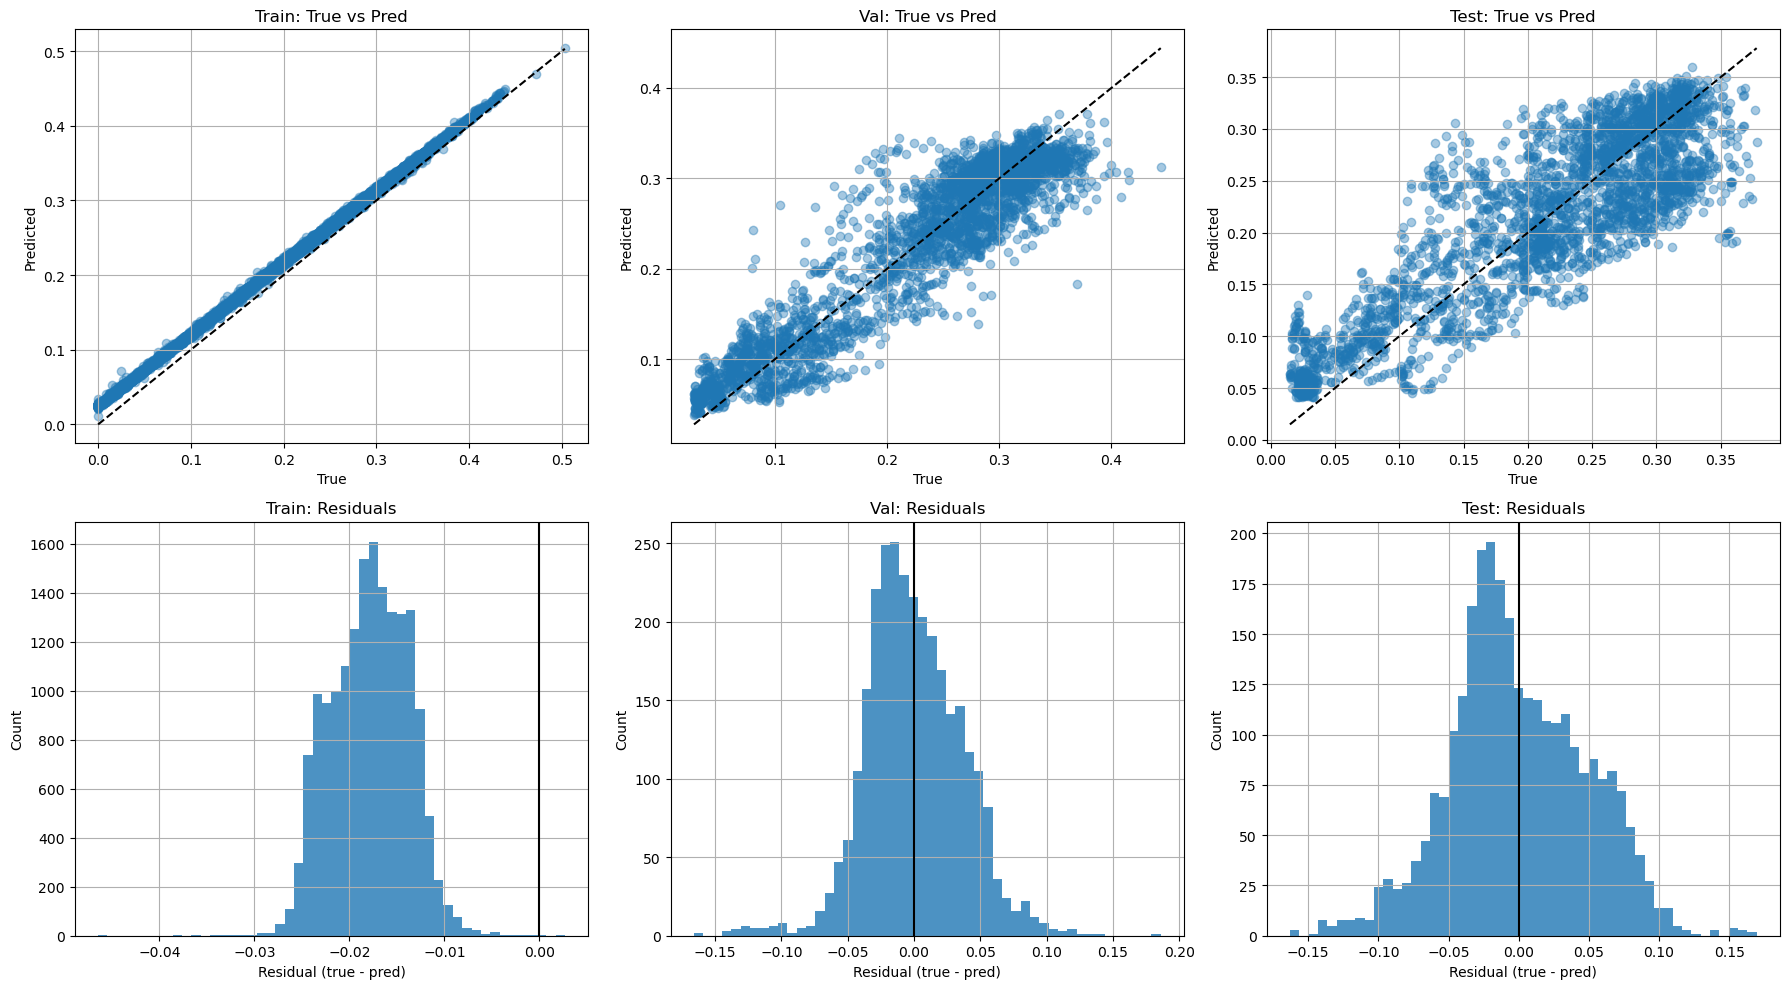

In [24]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train_cal, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val_cal,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test_cal,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train_cal, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val_cal,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test_cal,  "Test: Residuals")

plt.tight_layout()
plt.show()

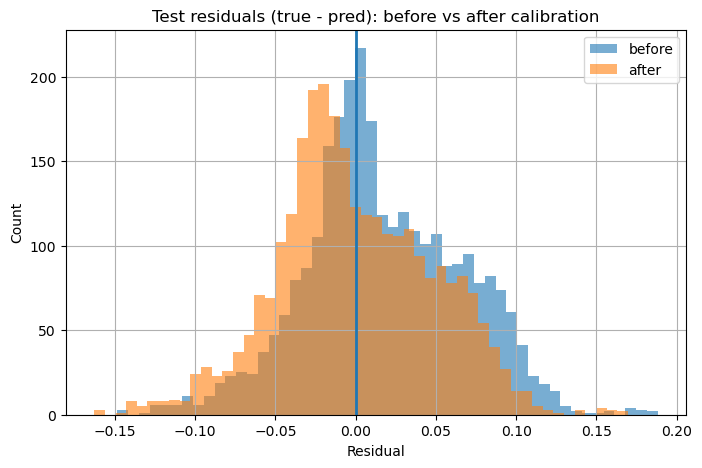

In [25]:
res_before = y_test - yhat_test
res_after  = y_test - yhat_test_cal

plt.figure()
plt.hist(res_before, bins=50, alpha=0.6, label="before")
plt.hist(res_after,  bins=50, alpha=0.6, label="after")
plt.axvline(0, linewidth=2)
plt.title("Test residuals (true - pred): before vs after calibration")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.legend()
plt.show()

### 7.4 Feature Importance

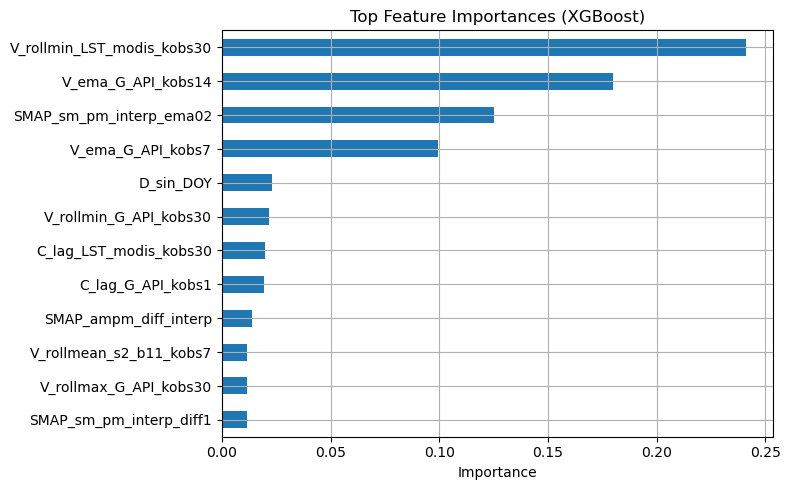

V_rollmin_LST_modis_kobs30    0.241251
V_ema_G_API_kobs14            0.179993
SMAP_sm_pm_interp_ema02       0.125095
V_ema_G_API_kobs7             0.099181
D_sin_DOY                     0.023062
                                ...   
SMAP_sm_pm_interp_mask        0.000074
A_d_SMAP_sm_interp_kobs1      0.000011
G_DSLR_isnan                  0.000000
SMAP_sm_interp_mask           0.000000
SMAP_sm_am_interp_mask        0.000000
Length: 108, dtype: float32

In [26]:
importances = pd.Series(model_xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 8. Evaluation

### 8.1 Test Metrics

In [27]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test_cal),
    "RMSE": rmse(y_test, yhat_test_cal),
    "R2":   r2_score(y_test, yhat_test_cal),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.039309,0.048865,0.727043,2829


### 8.2 Test Prediction Scatter

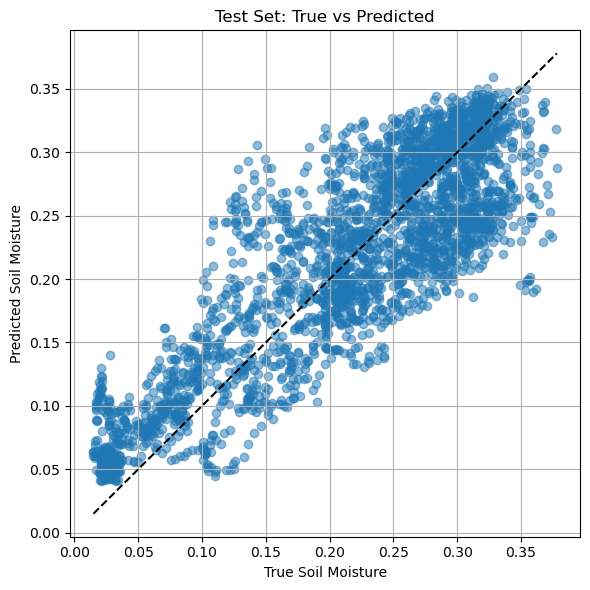

In [28]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test_cal, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.3 Bias

In [29]:
print(
    f"""
Residual diagnostics
--------------------
VAL  residual mean : {float((y_val.values - yhat_val_cal).mean()): .6f}
TEST residual mean : {float((y_test.values - yhat_test_cal).mean()): .6f}

Prediction ranges
-----------------
VAL  range : {float(yhat_val_cal.min()): .6f} to {float(yhat_val_cal.max()): .6f}
TEST range : {float(yhat_test_cal.min()): .6f} to {float(yhat_test_cal.max()): .6f}
"""
)


Residual diagnostics
--------------------
VAL  residual mean : -0.000000
TEST residual mean : -0.000641

Prediction ranges
-----------------
VAL  range :  0.038253 to  0.371556
TEST range :  0.041059 to  0.359436



## 9. Analysis

### What Stands Out

1. **Clear Generalization Gap (Especially for XGB)**

XGB
- Train $R^2 = 0.9997$
- Val $R^2 = 0.836$
- Test $R^2 = 0.692$

RF
- Val $R^2 = 0.845$
- Test $R^2 = 0.761$

> XGB fits training almost perfectly but drops much harder on test than RF. That suggests sensitivity to temporal distribution shift rather than missing signal.

> Why does XGB collapse more from `val` to `test` than RF?

2. **Systematic Bias in XGB**

Base XGB test bias:

$$
\text{bias} = \mathbb{E}[y - \hat{y}] \approx 0.017
$$

> So XGB **under-predicts** on average.

After Ridge calibration:
- Bias ≈ 0
- Test $R^2$ improves from $0.692 \rightarrow 0.727$

Calibration is:

$$
\hat{y}{\text{cal}} = a \hat{y}{\text{XGB}} + b
$$

> This means the issue is largely scale + offset mismatch, not structural failure.

3. **Stacking Behavior**

Stacked (XGB + RF → Ridge):
- Test $R^2 = 0.768$

Weights:

$$
w_{\text{XGB}} \approx 0.46, \quad w_{\text{RF}} \approx 0.55
$$

> XGB still carries real signal. RF is just more stable under shift

4. **Prediction Compression**

Test predictions slightly compress high soil moisture values. This matches the positive bias and suggests regression-to-mean under distribution shift

---

### HYP1: The test distribution is shifted

In [30]:
print("Mean y")
print("train:", y_train.mean())
print("val  :", y_val.mean())
print("test :", y_test.mean())

print("\nStd y")
print("train:", y_train.std())
print("val  :", y_val.std())
print("test :", y_test.std())

Mean y
train: 0.19487349752533586
val  : 0.2206039739636862
test : 0.2165383527748321

Std y
train: 0.10225711147072782
val  : 0.1007353671046573
test : 0.09354595019557466


### HYP2: XGB is overfitting small interactions

In [32]:
import json
print(json.dumps(model_xgb.get_params(), indent=4))

{
    "objective": "reg:squarederror",
    "base_score": null,
    "booster": null,
    "callbacks": null,
    "colsample_bylevel": null,
    "colsample_bynode": null,
    "colsample_bytree": 0.75,
    "device": null,
    "early_stopping_rounds": null,
    "enable_categorical": false,
    "eval_metric": null,
    "feature_types": null,
    "feature_weights": null,
    "gamma": 0.0,
    "grow_policy": null,
    "importance_type": null,
    "interaction_constraints": null,
    "learning_rate": 0.05,
    "max_bin": null,
    "max_cat_threshold": null,
    "max_cat_to_onehot": null,
    "max_delta_step": null,
    "max_depth": 7,
    "max_leaves": null,
    "min_child_weight": 3,
    "missing": NaN,
    "monotone_constraints": null,
    "multi_strategy": null,
    "n_estimators": 4000,
    "n_jobs": -1,
    "num_parallel_tree": null,
    "random_state": 42,
    "reg_alpha": 0.05,
    "reg_lambda": 2.0,
    "sampling_method": null,
    "scale_pos_weight": null,
    "subsample": 0.9,
    "tr

### HYP3: Residual variance increases in test

`RMSE`
```yaml
  train: 0.0017379010794451096
  val:   0.040728994371265426
  test:  0.05192666924627716
```

In [33]:
val_rmse = 0.040728994371265426
test_rmse = 0.05192666924627716

print("Val RMSE:", val_rmse)
print("Test RMSE:", test_rmse)

Val RMSE: 0.040728994371265426
Test RMSE: 0.05192666924627716


### Conclusion

The generalization gap exists because:
  1. Test distribution is wetter and less variable than train
  2. XGB is complex enough to over-specialize
  3. Boosting is more sensitive to temporal drift than RF

This is not a feature problem. It is a temporal nonstationarity + model capacity issue.

**Possible Solutions:**
- A) Make XGB more stable
- B) Accept shift and rely on stacking
- C) Explicitly model regime shift

---

### HYP4: Is the bias constant across moisture range?

In [34]:
test_df["residual"] = y_test - yhat_test
test_df["pred"] = yhat_test

bins = pd.qcut(test_df["pred"], q=5)
print(test_df.groupby(bins)["residual"].mean())

pred
(0.0161, 0.115]    0.008059
(0.115, 0.19]      0.035064
(0.19, 0.234]      0.036834
(0.234, 0.282]     0.011377
(0.282, 0.347]    -0.006189
Name: residual, dtype: float64


In [35]:
test_df["year"] = pd.to_datetime(test_df["date"]).dt.year
print(test_df.groupby("year")["residual"].mean())

year
2023    0.037508
2024    0.020133
2025    0.012040
Name: residual, dtype: float64


### Conclusion

The bias is driven by temporal distribution shift:
- Test period has higher mean moisture
- Test variance is slightly lower
- Boosting amplifies small baseline shifts

This is a global miscalibration issue, not structural model failure...

**Possible Solutions:**
- A) Post-hoc calibration (linear or isotonic)
- B) Weight recent years more during training
- C) Rolling-window or drift-aware retraining
- D) Slightly stronger regularization to reduce over-specialization

---

### HYP5: Are we comparing the same rows cleanly, and what are the raw residuals and errors per model?

In [36]:
diag = test_df.copy()

if "date" in diag.columns:
    diag["date"] = pd.to_datetime(diag["date"], errors="coerce")
    diag["year"] = diag["date"].dt.year
    diag["month"] = diag["date"].dt.month
else:
    diag["year"] = np.nan
    diag["month"] = np.nan

diag["y"] = np.asarray(y_test).ravel()
diag["pred_xgb"] = np.asarray(yhat_test).ravel()
diag["pred_rf"]  = np.asarray(yhat_test_rf).ravel()

diag["res_xgb"] = diag["y"] - diag["pred_xgb"]
diag["res_rf"]  = diag["y"] - diag["pred_rf"]

diag["abs_xgb"] = diag["res_xgb"].abs()
diag["abs_rf"]  = diag["res_rf"].abs()

diag["sq_xgb"] = diag["res_xgb"] ** 2
diag["sq_rf"]  = diag["res_rf"] ** 2

diag["rf_better_abs"] = diag["abs_rf"] < diag["abs_xgb"]
diag["rf_better_sq"]  = diag["sq_rf"] < diag["sq_xgb"]

print("Rows:", len(diag))
print("RF better (abs):", float(diag["rf_better_abs"].mean()))
print("RF better (sq) :", float(diag["rf_better_sq"].mean()))
print("Mean abs err XGB:", float(diag["abs_xgb"].mean()))
print("Mean abs err RF :", float(diag["abs_rf"].mean()))

Rows: 2829
RF better (abs): 0.5648639095086603
RF better (sq) : 0.5648639095086603
Mean abs err XGB: 0.040087031531856436
Mean abs err RF : 0.03650927675432996


### HYP6: Are the residuals correlated?

In [37]:
corr_res = np.corrcoef(diag["res_xgb"], diag["res_rf"])[0, 1]
corr_abs = np.corrcoef(diag["abs_xgb"], diag["abs_rf"])[0, 1]

print("Corr(residuals xgb, rf):", float(corr_res))
print("Corr(abs error xgb, rf):", float(corr_abs))

diag["abs_gap_xgb_minus_rf"] = diag["abs_xgb"] - diag["abs_rf"]
print("\nAbs error gap (XGB - RF):")
print(diag["abs_gap_xgb_minus_rf"].describe())

Corr(residuals xgb, rf): 0.9084762790831892
Corr(abs error xgb, rf): 0.8196912590298092

Abs error gap (XGB - RF):
count    2829.000000
mean        0.003578
std         0.018917
min        -0.062191
25%        -0.008198
50%         0.002799
75%         0.015679
max         0.065396
Name: abs_gap_xgb_minus_rf, dtype: float64


## Key Findings
- RF has lower mean absolute error than XGB:
  $$
  \text{MAE}_{\text{RF}} = 0.0365 \quad vs \quad \text{MAE}_{\text{XGB}} = 0.0401
  $$

- RF performs better on ~56% of test samples.

- Residual correlation:
  $$
  \text{Corr}(e_{\text{XGB}}, e_{\text{RF}}) \approx 0.91
  $$

- Absolute error correlation:
  $$
  \text{Corr}(|e_{\text{XGB}}|, |e_{\text{RF}}|) \approx 0.82
  $$

### Conclusion

XGB and RF are making highly similar errors. Stacking improves performance not because the models capture fundamentally different regimes, but because:

- RF is slightly more stable under temporal shift.
- XGB carries real signal but is mildly miscalibrated.
- Combining them reduces variance and smooths global bias.

The gain from stacking is primarily bias/variance smoothing, not strong model complementarity.

---

### HYP7: Where does RF win?

In [38]:
# year
print("\nRF better by year (abs):")
print(diag.groupby("year")["rf_better_abs"].mean())

# prediction bin
bins = pd.qcut(diag["pred_xgb"], q=5, duplicates="drop")
print("\nRF better by prediction bin:")
print(diag.groupby(bins)["rf_better_abs"].mean())

# absolute residual magnitude (hard cases)
hard_bins = pd.qcut(diag["abs_xgb"], q=5, duplicates="drop")
print("\nRF better by XGB difficulty:")
print(diag.groupby(hard_bins)["rf_better_abs"].mean())


RF better by year (abs):
year
2023    0.835443
2024    0.570663
2025    0.540971
Name: rf_better_abs, dtype: float64

RF better by prediction bin:
pred_xgb
(0.0161, 0.115]    0.443463
(0.115, 0.19]      0.655477
(0.19, 0.234]      0.665487
(0.234, 0.282]     0.553004
(0.282, 0.347]     0.507067
Name: rf_better_abs, dtype: float64

RF better by XGB difficulty:
abs_xgb
(-0.00099077, 0.00962]    0.178445
(0.00962, 0.0227]         0.438163
(0.0227, 0.042]           0.575221
(0.042, 0.0703]           0.779152
(0.0703, 0.188]           0.853357
Name: rf_better_abs, dtype: float64


### Conclusion

- **Early Drift Sensitivity**
  - RF outperforms XGB on:
    - 83.5% of samples in 2023
    - ~55–57% in 2024–2025
  - XGB struggles most when temporal distribution shift is largest.

- **Mid-Range Instability**
  - RF dominates in the mid-moisture bins (~66% of cases).
  - This aligns with earlier evidence of slope compression in XGB.

- **High-Difficulty Rescue Effect**
  - When XGB errors are large, RF wins:
    $$
    \text{RF better on hardest 20\% of XGB cases} \approx 85\%
    $$
  - RF is more stable in high-error regions.

### Conclusion

Stacking improves performance not because the models learn fundamentally different regimes, but because:

- XGB is sensitive to temporal drift and mid-range curvature distortion
- RF is more robust under distribution shift
- RF consistently rescues XGB in difficult and drift-heavy scenarios

The stacking gain is primarily due to stability under non-stationarity rather than strong structural complementarity

---

### HYP8: Measuring compression directly (slope + bins)

In [39]:
y = diag["y"].to_numpy()
p = diag["pred_xgb"].to_numpy()

a, b = np.polyfit(p, y, deg=1)
print("Test: fit y ≈ a*pred + b")
print("a (slope):", float(a))
print("b (intercept):", float(b))

bins = pd.qcut(diag["pred_xgb"], q=10, duplicates="drop")
cal = diag.groupby(bins).agg(
    n=("y", "size"),
    pred_mean=("pred_xgb", "mean"),
    y_mean=("y", "mean"),
)
cal["y_minus_pred"] = cal["y_mean"] - cal["pred_mean"]
print("\nBinned calibration (by pred deciles):")
display(cal)

print("\nStd ratio (pred / y):", float(np.std(p) / np.std(y)))

Test: fit y ≈ a*pred + b
a (slope): 0.9435302655940146
b (intercept): 0.02828857887579128

Binned calibration (by pred deciles):


,n,pred_mean,y_mean,y_minus_pred
pred_xgb,,,,
"(0.0161, 0.0666]",283,0.040360,0.047276,0.006916
"(0.0666, 0.115]",283,0.089834,0.099035,0.009202
"(0.115, 0.164]",283,0.141071,0.169979,0.028907
"(0.164, 0.19]",283,0.177353,0.218572,0.041220
"(0.19, 0.214]",283,0.202315,0.244919,0.042604
"(0.214, 0.234]",282,0.224009,0.255053,0.031044
"(0.234, 0.258]",283,0.245240,0.266283,0.021043
"(0.258, 0.282]",283,0.269281,0.270993,0.001712
"(0.282, 0.302]",283,0.291265,0.287095,-0.004170



Std ratio (pred / y): 0.903978468803755


Slope by year

In [40]:
for yr, g in diag.groupby("year"):
    y_ = g["y"].to_numpy()
    p_ = g["pred_xgb"].to_numpy()
    a_, b_ = np.polyfit(p_, y_, deg=1)
    print(f"\nYear {yr}")
    print("  slope:", float(a_))
    print("  intercept:", float(b_))
    print("  std ratio:", float(np.std(p_) / np.std(y_)))


Year 2023
  slope: 0.3846581864889875
  intercept: 0.19181742248167172
  std ratio: 0.6597954659130606

Year 2024
  slope: 0.8932316863557345
  intercept: 0.04155539815271769
  std ratio: 0.9646192710749185

Year 2025
  slope: 0.9964559905882898
  intercept: 0.012730615426510676
  std ratio: 0.8535638587006048


### Conclusion

Prediction compression is:
- Severe in 2023
- Mild in 2024
- Essentially gone in 2025

So the issue is:
  - Initial regime shift at start of test period.

Boosting struggles more with abrupt drift, RF handles it better...stacking helps because RF pretty much rescues 2023

> **Core problem**: temporal transition

In [41]:
print("Overall Test R2 (XGB):", float(r2_score(diag["y"], diag["pred_xgb"])))

for yr, g in diag.groupby("year"):
    r2 = r2_score(g["y"], g["pred_xgb"])
    print(f"Year {yr} R2:", float(r2))

mask_no_2023 = diag["year"] != 2023
r2_no_2023 = r2_score(diag.loc[mask_no_2023, "y"],
                      diag.loc[mask_no_2023, "pred_xgb"])

print("\nTest R2 excluding 2023:", float(r2_no_2023))

Overall Test R2 (XGB): 0.6917631955323562
Year 2023 R2: -0.7731782496920108
Year 2024 R2: 0.6809859237297896
Year 2025 R2: 0.7083787740204192

Test R2 excluding 2023: 0.6964430413615139


In [42]:
train_df_recent = train_df.copy()
train_df_recent["date"] = pd.to_datetime(train_df_recent["date"])

cutoff_year = 2020
train_recent = train_df_recent[train_df_recent["date"].dt.year >= cutoff_year]

print("Original train size:", len(train_df))
print("Recent train size  :", len(train_recent))

X_train_recent = train_recent[FEATURE_COLS]
y_train_recent = train_recent[TARGET_COL]

xgb_recent = XGBRegressor(**model_xgb.get_params())
xgb_recent.fit(X_train_recent, y_train_recent)

yhat_test_recent = xgb_recent.predict(test_df[FEATURE_COLS])

print("\nTest R2 (recent-trained model):",
      float(r2_score(diag["y"], yhat_test_recent)))

Original train size: 16972
Recent train size  : 2717

Test R2 (recent-trained model): 0.7070464709344599


### HYP9: Why does 2023 perform so poorly?

In [43]:
train_y = y_train
test_2023 = diag[diag["year"] == 2023]["y"]

print("Train mean:", float(np.mean(train_y)))
print("2023 mean :", float(np.mean(test_2023)))

print("\nTrain std:", float(np.std(train_y)))
print("2023 std :", float(np.std(test_2023)))

print("\nTrain min/max:", float(np.min(train_y)), float(np.max(train_y)))
print("2023 min/max :", float(np.min(test_2023)), float(np.max(test_2023)))

Train mean: 0.19487349752533586
2023 mean : 0.28827848101265824

Train std: 0.10225409890244544
2023 std : 0.04572895842022871

Train min/max: 0.0 0.503
2023 min/max : 0.146 0.378


In [44]:
features_to_check = ["G_API", "SMAP_sm_pm_interp_ema02", "LST_modis"]

for f in features_to_check:
    if f in train_df.columns:
        train_mean = train_df[f].mean()
        test_2023_mean = test_df[test_df["date"].dt.year == 2023][f].mean()
        print(f"\nFeature: {f}")
        print("Train mean:", float(train_mean))
        print("2023 mean :", float(test_2023_mean))


Feature: G_API
Train mean: 43.04035869108933
2023 mean : 50.97278304594382

Feature: SMAP_sm_pm_interp_ema02
Train mean: 0.39502225554635206
2023 mean : 0.2976791375333556

Feature: LST_modis
Train mean: 287.54988714621095
2023 mean : 276.41109807549964


In [45]:
train_missing = train_df[FEATURE_COLS].isna().mean().mean()
test2023_missing = test_df[test_df["date"].dt.year == 2023][FEATURE_COLS].isna().mean().mean()

print("Avg missing rate train :", float(train_missing))
print("Avg missing rate 2023  :", float(test2023_missing))

Avg missing rate train : 0.04565308001850544
Avg missing rate 2023  : 0.0


---

_Jakob Balkovec_